<a href="https://www.kaggle.com/code/lalit7881/healthcare-disease-prediction-dataset-eda?scriptVersionId=310648887" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/algozee/healthcare-disease-prediction-dataset/healthcare_disease_prediction_dataset.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/algozee/healthcare-disease-prediction-dataset/healthcare_disease_prediction_dataset.csv")

In [3]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
0,69,Male,High,High,High,Yes,No,No,35.671099,No,1,0,0,0,1,0,0,0,0,0
1,32,Male,Low,High,Normal,Yes,No,Yes,38.554188,Yes,0,1,0,0,0,0,0,1,0,0
2,89,Female,Normal,High,Normal,No,No,Yes,18.932964,Yes,1,0,0,0,0,0,0,0,0,0
3,78,Male,High,High,High,No,No,Yes,21.806350,Yes,0,1,1,0,1,0,0,1,0,0
4,38,Male,Low,Normal,Normal,Yes,Yes,Yes,37.552683,No,0,0,0,0,0,0,0,0,0,0


In [4]:
df.tail()

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
995,27,Female,Low,High,Normal,No,No,No,31.960176,Yes,1,0,0,0,0,0,0,0,0,0
996,51,Female,High,High,Normal,No,Yes,Yes,20.118492,Yes,0,0,0,0,0,0,0,0,0,0
997,72,Female,Normal,High,Normal,Yes,No,No,20.916536,Yes,0,0,0,0,0,0,0,0,0,0
998,49,Male,Normal,High,High,Yes,No,Yes,19.560143,Yes,0,0,0,0,0,1,0,0,0,0
999,67,Male,High,Normal,Normal,Yes,No,Yes,24.035803,Yes,0,1,1,0,0,0,1,1,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1000 non-null   int64  
 1   Gender               1000 non-null   object 
 2   Blood Pressure       1000 non-null   object 
 3   Cholesterol          1000 non-null   object 
 4   Glucose              1000 non-null   object 
 5   Smoking              1000 non-null   object 
 6   Alcohol Consumption  1000 non-null   object 
 7   Exercise             1000 non-null   object 
 8   BMI                  1000 non-null   float64
 9   Family History       1000 non-null   object 
 10  Heart Disease        1000 non-null   int64  
 11  Diabetes             1000 non-null   int64  
 12  Stroke               1000 non-null   int64  
 13  Kidney Disease       1000 non-null   int64  
 14  Cancer               1000 non-null   int64  
 15  Alzheimer's Disease  1000 non-null   in

In [6]:
df.describe()

,Age,BMI,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,52.881000,29.213037,0.253000,0.186000,0.134000,0.142000,0.10000,0.130000,0.10100,0.157000,0.082000,0.035000
std,20.958915,6.196368,0.434948,0.389301,0.340823,0.349225,0.30015,0.336472,0.30148,0.363983,0.274502,0.183872
min,18.000000,18.504881,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,34.750000,23.924004,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,52.500000,28.892349,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,71.000000,34.663806,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
max,89.000000,39.974048,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,1.000000,1.000000


In [7]:
df.isnull().sum()

Age                    0
Gender                 0
Blood Pressure         0
Cholesterol            0
Glucose                0
Smoking                0
Alcohol Consumption    0
Exercise               0
BMI                    0
Family History         0
Heart Disease          0
Diabetes               0
Stroke                 0
Kidney Disease         0
Cancer                 0
Alzheimer's Disease    0
COPD                   0
Liver Disease          0
Parkinson's Disease    0
Tuberculosis           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Age                      int64
Gender                  object
Blood Pressure          object
Cholesterol             object
Glucose                 object
Smoking                 object
Alcohol Consumption     object
Exercise                object
BMI                    float64
Family History          object
Heart Disease            int64
Diabetes                 int64
Stroke                   int64
Kidney Disease           int64
Cancer                   int64
Alzheimer's Disease      int64
COPD                     int64
Liver Disease            int64
Parkinson's Disease      int64
Tuberculosis             int64
dtype: object

In [10]:
df.columns

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol', 'Glucose', 'Smoking',
       'Alcohol Consumption', 'Exercise', 'BMI', 'Family History',
       'Heart Disease', 'Diabetes', 'Stroke', 'Kidney Disease', 'Cancer',
       'Alzheimer's Disease', 'COPD', 'Liver Disease', 'Parkinson's Disease',
       'Tuberculosis'],
      dtype='object')

In [11]:
df.shape

(1000, 20)

In [12]:
df.nunique()

Age                      72
Gender                    2
Blood Pressure            3
Cholesterol               2
Glucose                   2
Smoking                   2
Alcohol Consumption       2
Exercise                  2
BMI                    1000
Family History            2
Heart Disease             2
Diabetes                  2
Stroke                    2
Kidney Disease            2
Cancer                    2
Alzheimer's Disease       2
COPD                      2
Liver Disease             2
Parkinson's Disease       2
Tuberculosis              2
dtype: int64

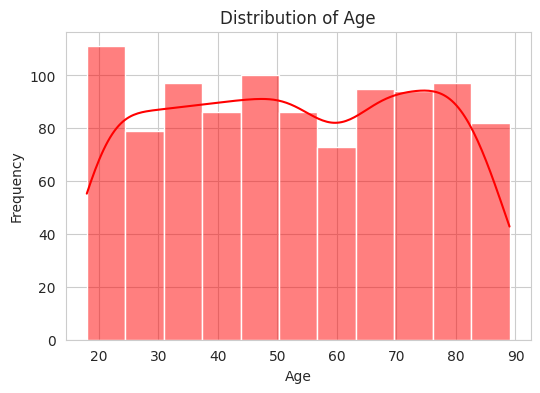

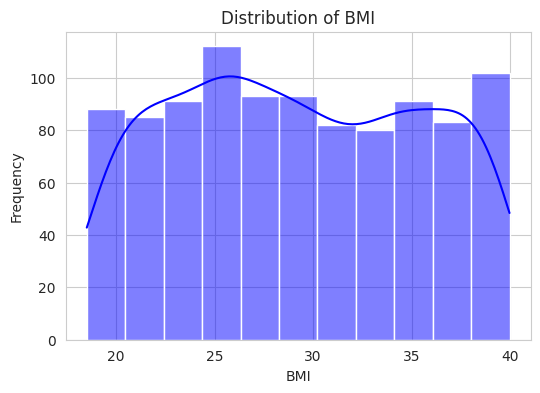

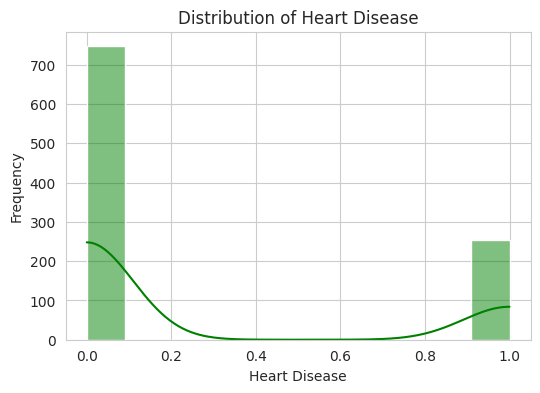

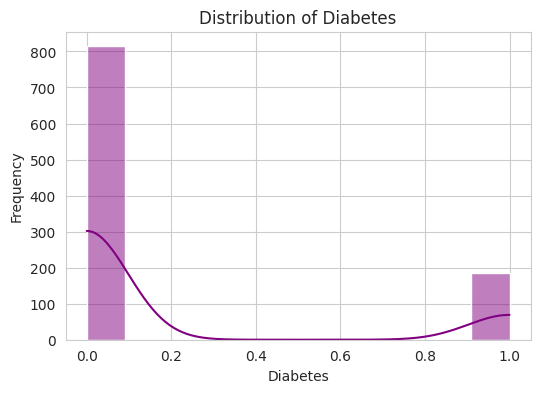

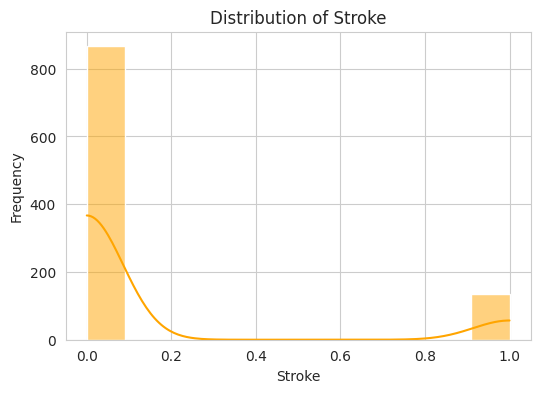

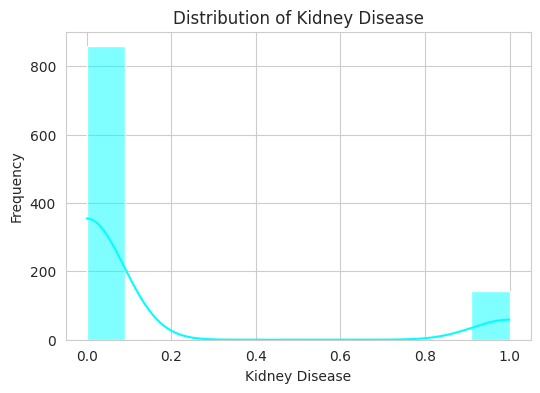

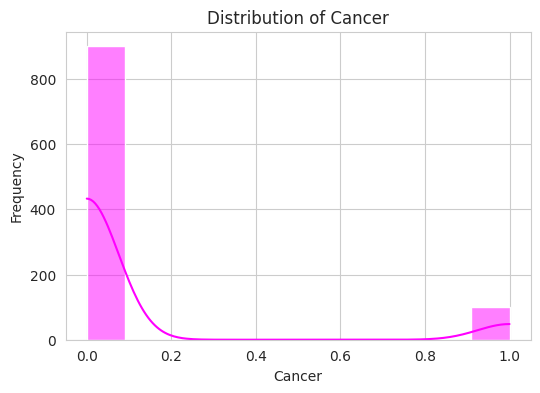

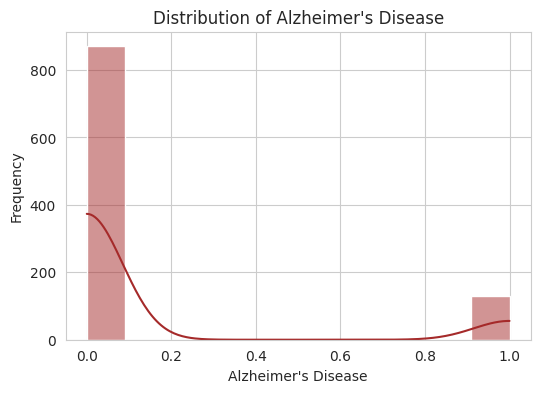

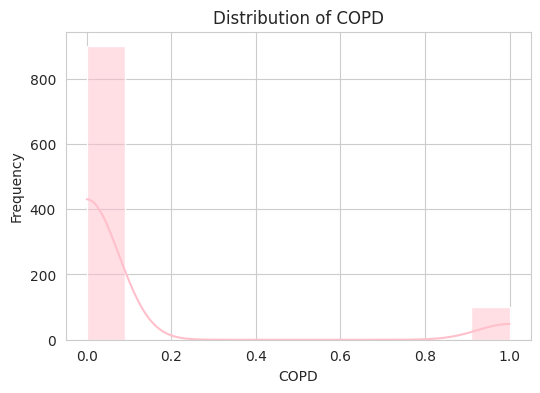

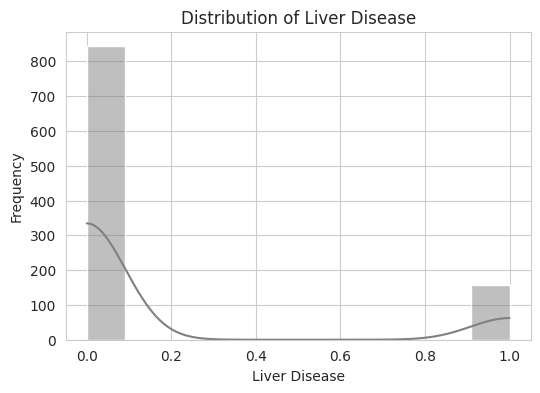

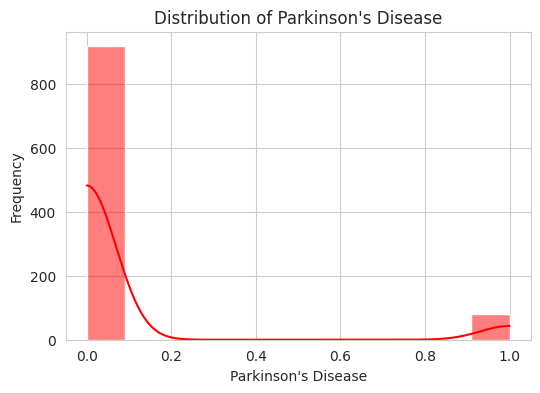

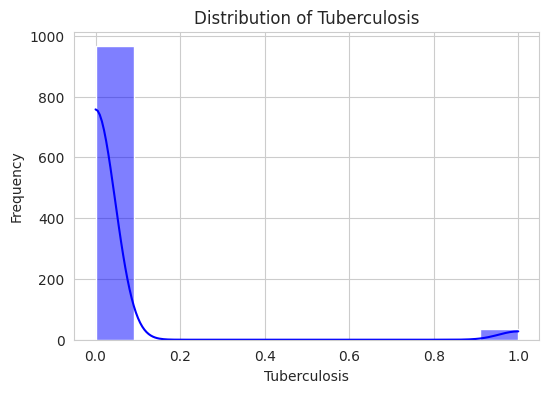

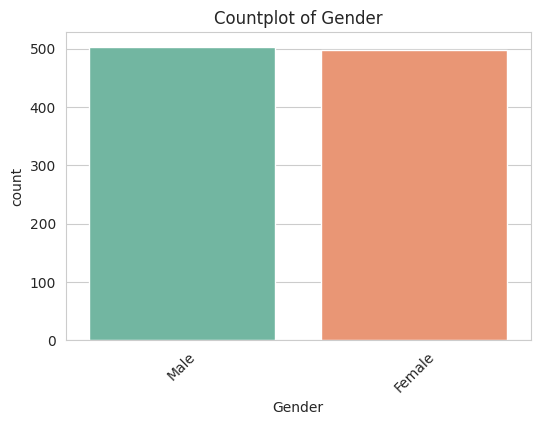

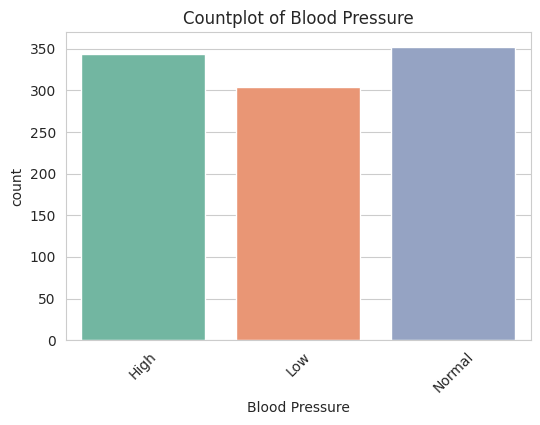

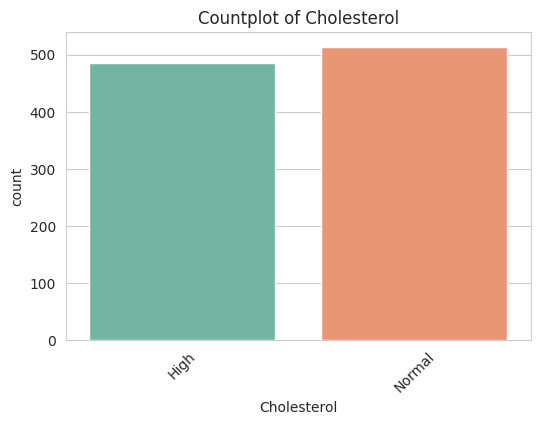

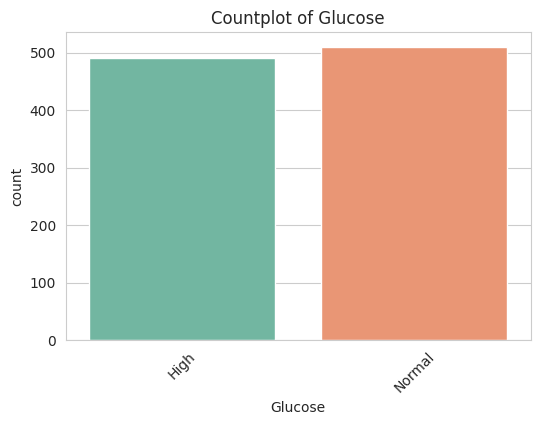

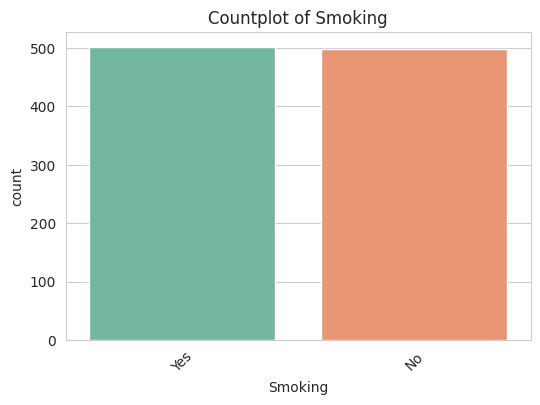

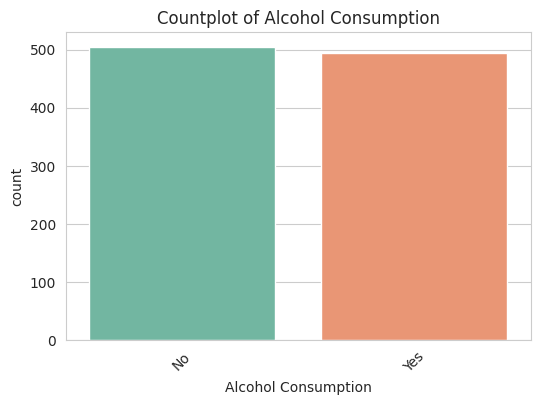

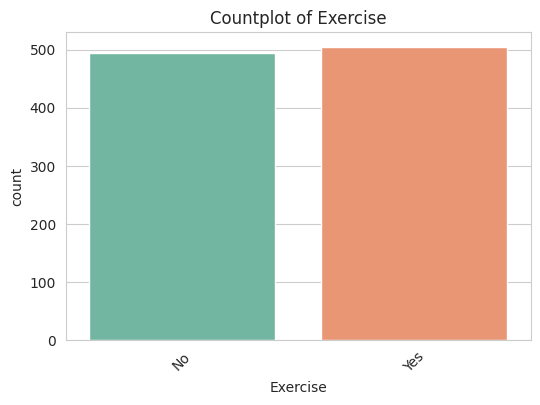

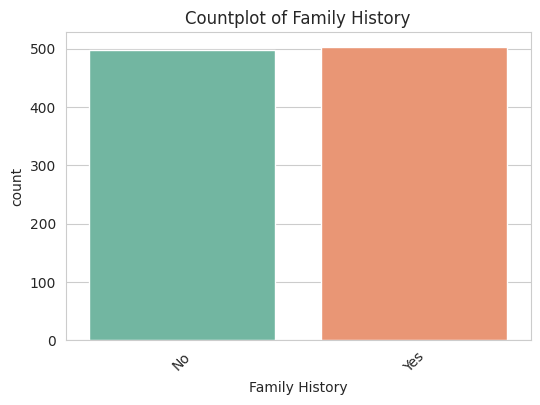

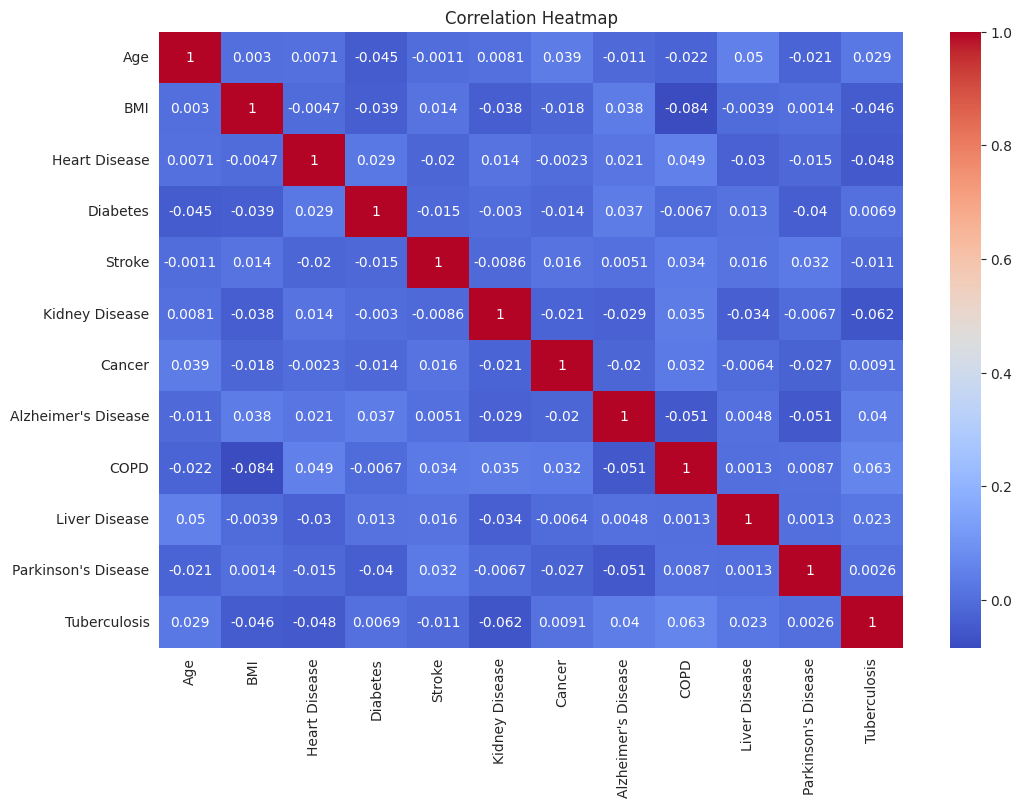

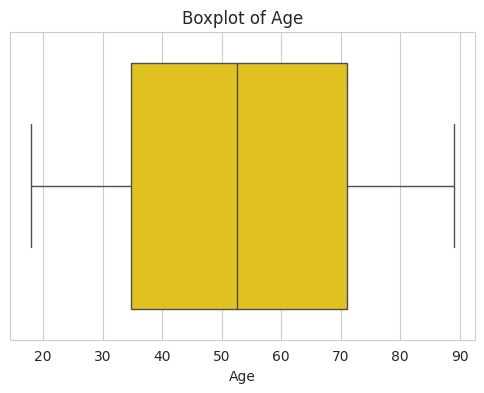

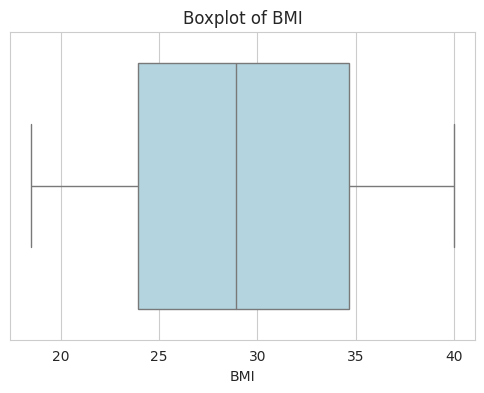

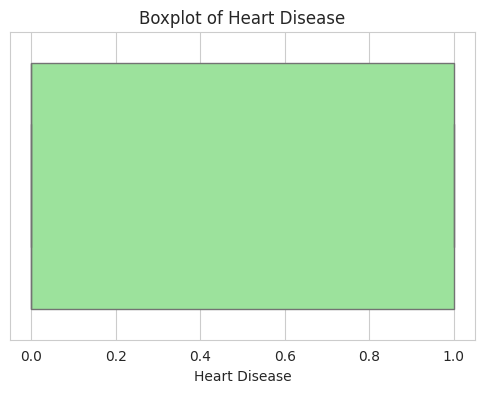

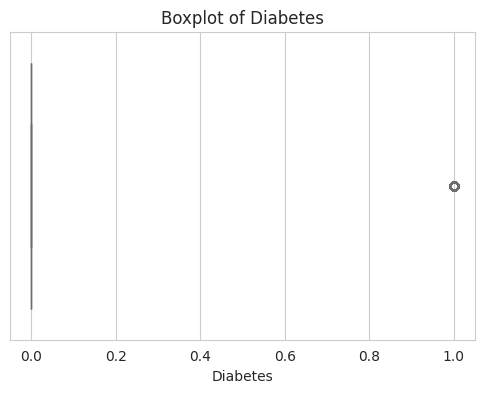

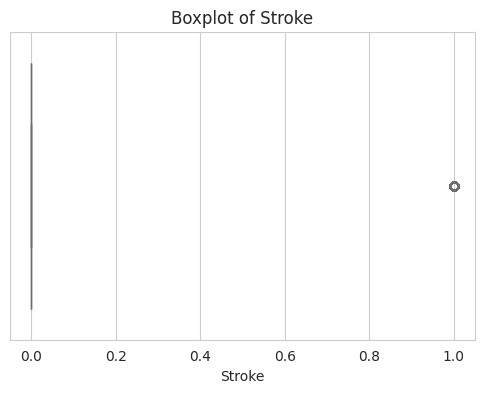

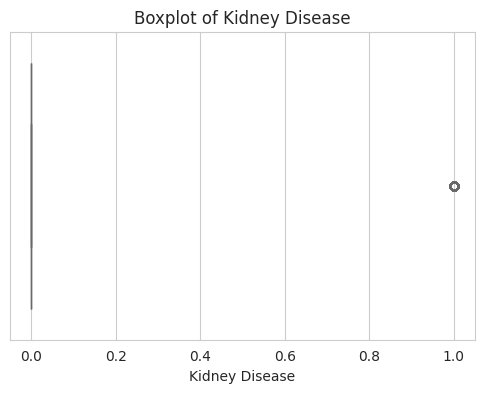

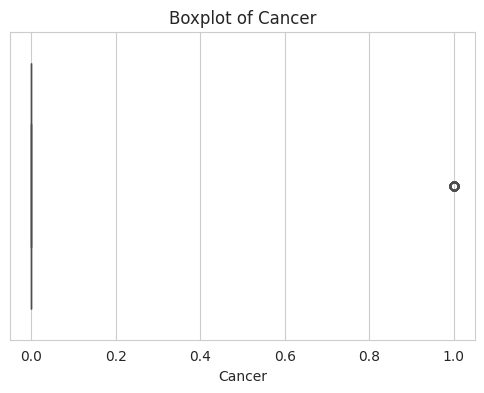

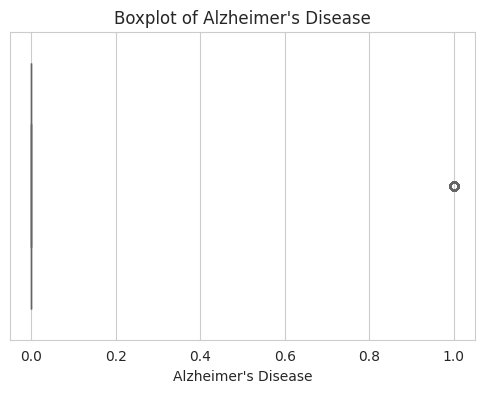

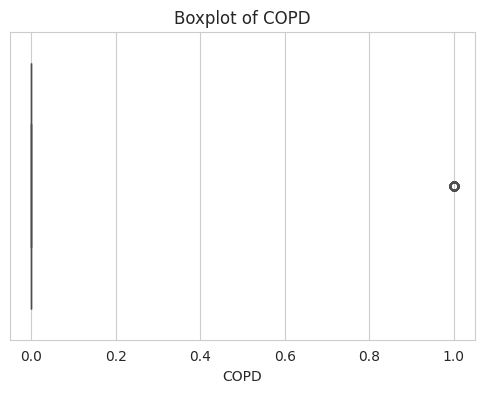

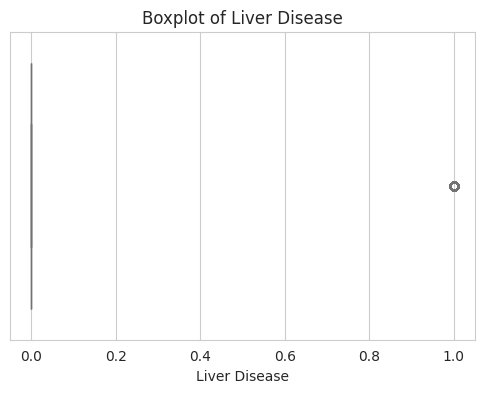

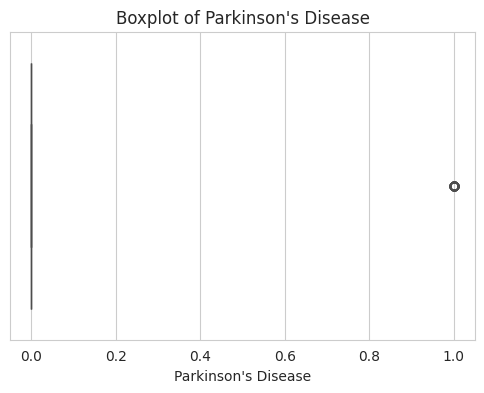

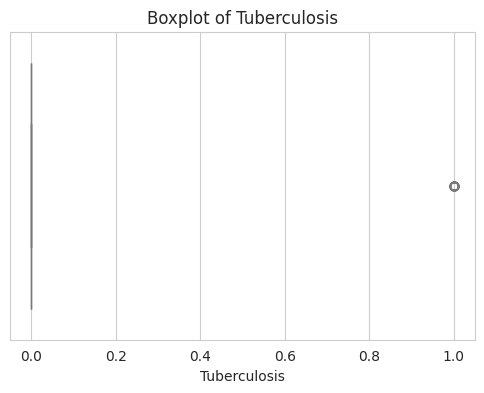

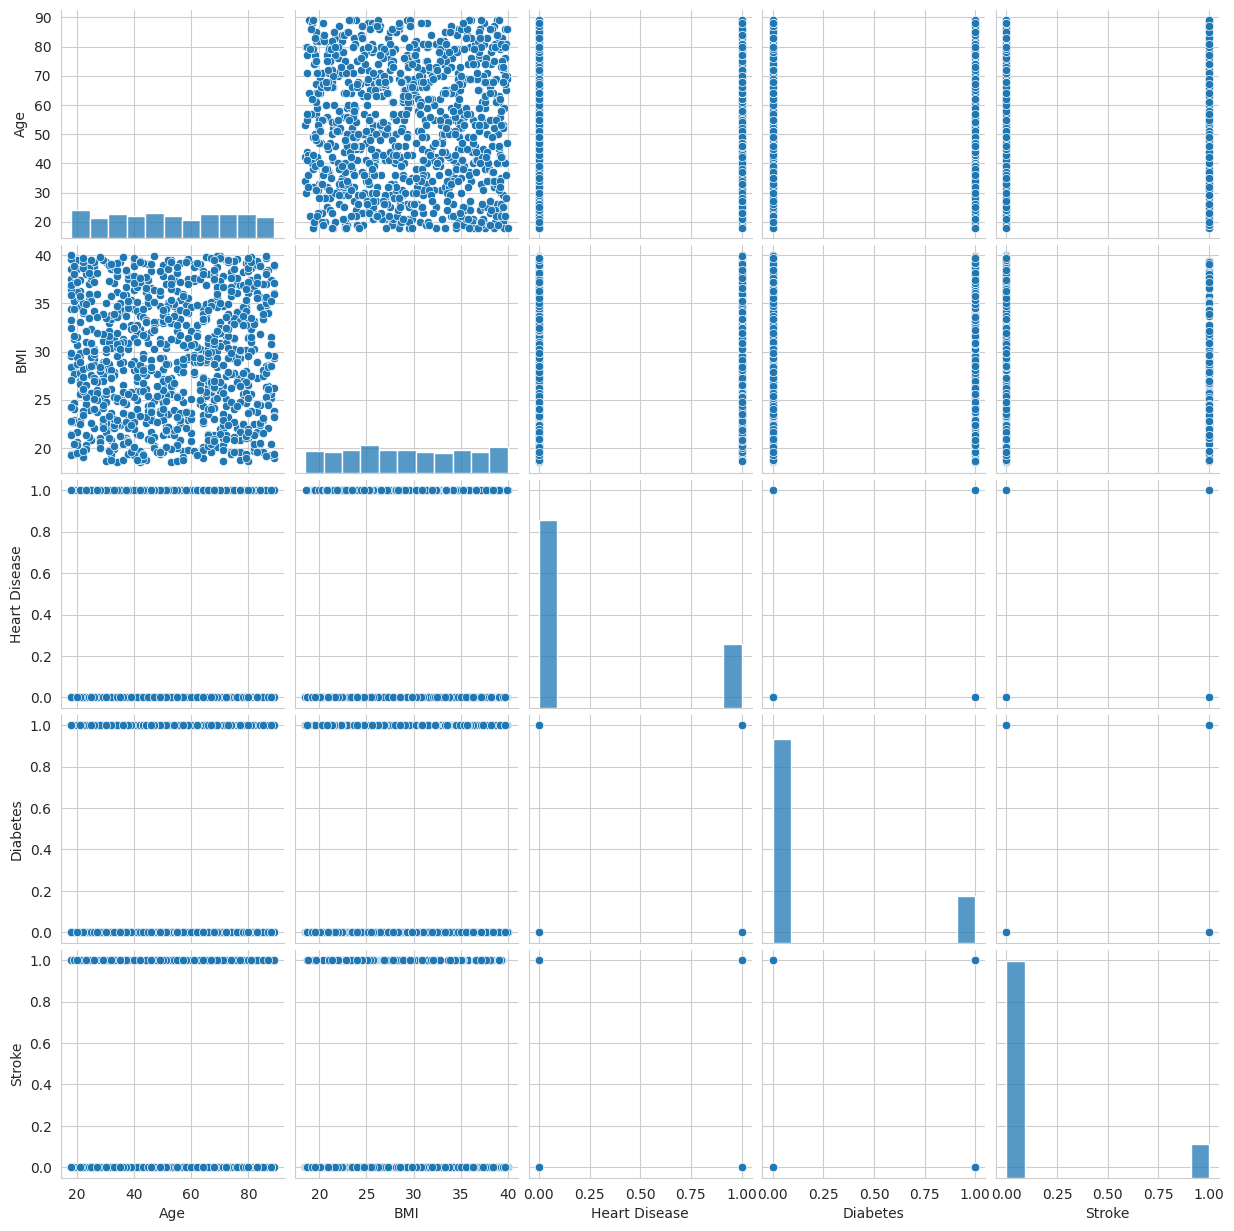

In [13]:
# Style
sns.set_style("whitegrid")

# Separate columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# -------------------------------
# 1. Histograms for Numerical Data
# -------------------------------
colors = ['red','blue','green','purple','orange','cyan','magenta','brown','pink','gray']

for i, col in enumerate(num_cols):
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color=colors[i % len(colors)])
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# -------------------------------
# 2. Countplots for Categorical Data
# -------------------------------
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col], palette="Set2")
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()

# -------------------------------
# 3. Correlation Heatmap
# -------------------------------
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# -------------------------------
# 4. Boxplots for Outliers
# -------------------------------
box_colors = ['gold','lightblue','lightgreen','salmon','violet','tan','lime','coral','aqua','plum']

for i, col in enumerate(num_cols):
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color=box_colors[i % len(box_colors)])
    plt.title(f"Boxplot of {col}")
    plt.show()

# -------------------------------
# 5. Pairplot (Important Features)
# -------------------------------
sns.pairplot(df[num_cols[:5]], palette="husl")
plt.show()

## Feature engineering


Logistic Regression
Accuracy: 0.745
Confusion Matrix:
 [[149   0]
 [ 51   0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.74      1.00      0.85       149
           1       0.00      0.00      0.00        51

    accuracy                           0.74       200
   macro avg       0.37      0.50      0.43       200
weighted avg       0.56      0.74      0.64       200


Decision Tree
Accuracy: 0.625
Confusion Matrix:
 [[114  35]
 [ 40  11]]
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.77      0.75       149
           1       0.24      0.22      0.23        51

    accuracy                           0.62       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.61      0.62      0.62       200


Random Forest
Accuracy: 0.73
Confusion Matrix:
 [[146   3]
 [ 51   0]]
Classification Report:
               precision    recall  f1-score   supp

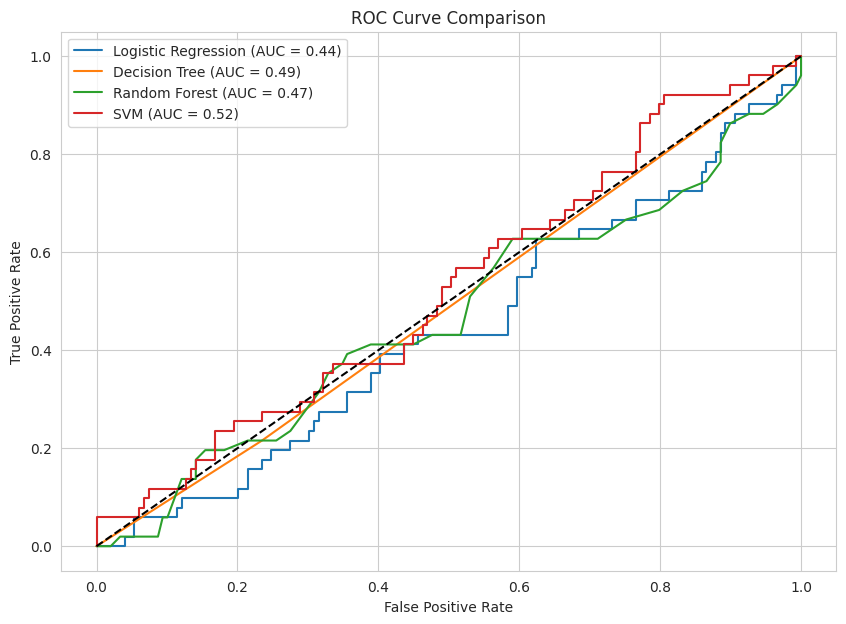


Final Accuracy Comparison:
Logistic Regression: 0.7450
Decision Tree: 0.6250
Random Forest: 0.7300
SVM: 0.7450


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# ================================
# 3. Define Target & Features
# ================================
target = "Heart Disease"   # You can change target if needed

X = df.drop(columns=[target])
y = df[target]

# ================================
# 4. Encode Target
# ================================
le_target = LabelEncoder()
y = le_target.fit_transform(y)

# ================================
# 5. Train-Test Split (NO LEAKAGE)
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ================================
# 6. Encode Categorical Features (TRAIN ONLY)
# ================================
cat_cols = X_train.select_dtypes(include=['object']).columns

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    encoders[col] = le

# ================================
# 7. Feature Scaling
# ================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# 8. Models
# ================================
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

# ================================
# 9. Train + Evaluate
# ================================
results = {}

plt.figure(figsize=(10,7))

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# ================================
# 10. Plot ROC Curve
# ================================
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ================================
# 11. Accuracy Summary
# ================================
print("\nFinal Accuracy Comparison:")
for k,v in results.items():
    print(f"{k}: {v:.4f}")

## Thank you....pls upvote!!!!!!!!!!